# Метод 2 — MLP. Часть 3: holdout, Split CP, монотонность

In [1]:
from pathlib import Path
import sys

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_2_mlp'
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from core.config import SEED, ALPHA, INNER_CALIB_FRAC, MODEL_DIR, TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import LOSS_REGISTRY, smlar, smlar_per_target, monotonicity_violation, monotonicity_violation_per_pair
from core.conformal import MultiTargetSplitCP
from core.ci import ConformalEvaluation, aggregate_cp_coverage, seeded_train_calib_split
from core.reporting import make_result, save_method_results

set_seed(SEED)
data = load_unified_data()
split = data['split']
X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)
train_idx = split['train_idx']
holdout_idx = split['holdout_idx']
folds = split['folds']
print('X:', X.shape, 'y:', y.shape, 'folds:', len(folds))


X: (1008, 39) y: (1008, 3) folds: 5


In [3]:
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(64, 3), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)


def _standardize(X_tr, X_te):
    mu = X_tr.mean(axis=0); sd = X_tr.std(axis=0) + 1e-6
    return (X_tr - mu) / sd, (X_te - mu) / sd, mu, sd


def _train_one(X_tr, y_tr, X_va, y_va, loss_name,
                epochs=160, patience=20, batch_size=64, lr=1e-3, wd=1e-4):
    set_seed(SEED)
    model = ImprovedMLP(input_dim=X_tr.shape[1])
    loss_fn = LOSS_REGISTRY[loss_name]()
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32)
    Xva_t = torch.tensor(X_va, dtype=torch.float32)
    yva_t = torch.tensor(y_va, dtype=torch.float32)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    best_val = float('inf'); bad = 0; history = []; best_state = None
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); optim.step()
        model.eval()
        with torch.no_grad():
            pred_va = model(Xva_t).cpu().numpy()
        v = smlar(yva_t.numpy(), pred_va)
        history.append(v)
        if v < best_val - 1e-3:
            best_val = v; bad = 0
            best_state = {k: t.detach().clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def _predict_np(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).cpu().numpy()


#### CV=5 для всех 6 потерь + Split CP внутри каждого фолда

In [4]:
def _run_loss(loss_name, X, y, train_idx, holdout_idx, folds):
    fold_smlar = []
    fold_smlar_pt = []
    fold_mono = []
    fold_mono_pair = []
    cp_evals = []
    for fold_i, (tr, va) in enumerate(folds):
        n_tr = len(tr)
        sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
        sub_idx = tr[sub_local]
        cal_idx = tr[cal_local]
        X_sub = X.iloc[sub_idx].values
        y_sub = y.iloc[sub_idx].values
        X_cal = X.iloc[cal_idx].values
        y_cal = y.iloc[cal_idx].values
        X_va = X.iloc[va].values
        y_va = y.iloc[va].values
        X_sub_s, X_cal_s, mu, sd = _standardize(X_sub, X_cal)
        X_va_s = (X_va - mu) / sd
        model, _ = _train_one(X_sub_s, y_sub, X_va_s, y_va, loss_name)
        pred_va = np.clip(_predict_np(model, X_va_s), 0.0, 1.0)
        pred_cal = np.clip(_predict_np(model, X_cal_s), 0.0, 1.0)
        fold_smlar.append(smlar(y_va, pred_va))
        fold_smlar_pt.append(smlar_per_target(y_va, pred_va))
        fold_mono.append(monotonicity_violation(pred_va))
        fold_mono_pair.append(monotonicity_violation_per_pair(pred_va))
        cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y_cal, pred_cal)
        lo, hi = cp.predict(pred_va)
        cp_evals.append(ConformalEvaluation(
            y_true=y_va.astype(np.float64),
            y_pred=pred_va.astype(np.float64),
            lower=lo, upper=hi,
            quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
        ))
    X_tr_all = X.iloc[train_idx].values
    y_tr_all = y.iloc[train_idx].values
    X_ho = X.iloc[holdout_idx].values
    y_ho = y.iloc[holdout_idx].values
    X_tr_s, X_ho_s, _, _ = _standardize(X_tr_all, X_ho)
    full_model, _ = _train_one(X_tr_s, y_tr_all, X_ho_s, y_ho, loss_name)
    pred_ho = np.clip(_predict_np(full_model, X_ho_s), 0.0, 1.0)
    if loss_name == 'smlar_smooth':
        MODEL_DIR.mkdir(parents=True, exist_ok=True)
        torch.save(full_model.state_dict(), MODEL_DIR / 'best_mlp_smlar_smooth.pt')
    cp_agg = aggregate_cp_coverage(cp_evals)

    cv_smlar_pt_mean = {t: float(np.mean([d[t] for d in fold_smlar_pt])) for t in TARGETS}
    cv_smlar_pt_std = {t: float(np.std([d[t] for d in fold_smlar_pt], ddof=0)) for t in TARGETS}
    cv_mono_pair_mean = {
        k: float(np.mean([d[k] for d in fold_mono_pair]))
        for k in ('y1_vs_y2', 'y2_vs_y3')
    }
    ho_mono_pair = monotonicity_violation_per_pair(pred_ho)

    return {
        'name': f'mlp-{loss_name}',
        'loss': loss_name,
        'pred_ho': pred_ho,
        'y_ho': y_ho,
        'cv_fold_smlar_per_target': fold_smlar_pt,
        'cv_fold_mono_pair': fold_mono_pair,
        'cv': {
            'smlar_flat_mean': float(np.mean(fold_smlar)),
            'smlar_flat_std':  float(np.std(fold_smlar, ddof=0)),
            'smlar_per_target': cv_smlar_pt_mean,
            'smlar_per_target_std': cv_smlar_pt_std,
            'monotone_viol_mean': float(np.mean(fold_mono)),
            'monotone_viol_per_pair': cv_mono_pair_mean,
        },
        'holdout': {
            'smlar_flat': float(smlar(y_ho, pred_ho)),
            'smlar_per_target': smlar_per_target(y_ho, pred_ho),
            'monotone_viol': float(monotonicity_violation(pred_ho)),
            'monotone_viol_per_pair': ho_mono_pair,
        },
        'ci': {
            'type': 'split_cp',
            'alpha': ALPHA,
            'coverage_per_target': cp_agg['coverage_per_target'],
            'width_per_target': cp_agg['width_per_target'],
        },
    }


losses_to_try = ['mse', 'mae', 'huber', 'msle', 'rmsle', 'smlar_smooth']
variants = []
for ln in losses_to_try:
    t0 = time.time()
    v = _run_loss(ln, X, y, train_idx, holdout_idx, folds)
    print(f"  mlp-{ln:14s}  CV SMLAR={v['cv']['smlar_flat_mean']:6.2f}% ± {v['cv']['smlar_flat_std']:.2f}")
    variants.append(v)


  mlp-mse             CV SMLAR= 67.86% ± 4.00
  mlp-mae             CV SMLAR= 37.80% ± 1.67
  mlp-huber           CV SMLAR= 50.55% ± 2.51
  mlp-msle            CV SMLAR= 30.78% ± 1.44
  mlp-rmsle           CV SMLAR= 42.91% ± 2.69
  mlp-smlar_smooth    CV SMLAR= 29.17% ± 1.99


#### scatter pred vs actual по targets

In [5]:
import matplotlib.pyplot as plt

winner = min(variants, key=lambda v: v['cv']['smlar_flat_mean'])
print('Победитель:', winner['name'])
pred_ho = np.asarray(winner['pred_ho'])
y_ho_arr = np.asarray(winner['y_ho'])
target_labels = list(TARGETS)

n_steps = 10
n_rows = pred_ho.shape[0]
order = np.argsort(y_ho_arr[:, 0])  
step_size = max(1, n_rows // n_steps)

for ti, tname in enumerate(target_labels):
    short = f'y{ti + 1}'
    for k in range(1, n_steps + 1):
        take = min(n_rows, k * step_size)
        idx = order[:take]
        fig, ax = plt.subplots(figsize=(6.0, 6.0))
        ax.scatter(y_ho_arr[idx, ti], pred_ho[idx, ti],
                   s=22, alpha=0.55, color='#2a6fb8', edgecolor='white', linewidth=0.4)
        ax.plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1.0)
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_xlabel(f'actual {tname}')
        ax.set_ylabel(f'pred {tname}')
        ax.set_title(f'MLP {winner["loss"]} — {tname} ({take}/{n_rows} кампаний)')
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f'fig_target_{short}_{k:03d}.png', dpi=110, bbox_inches='tight')
        plt.close(fig)
print('Сохранено', 3 * n_steps, 'PNG для трёх целей.')


Победитель: mlp-smlar_smooth
Сохранено 30 PNG для трёх целей.


#### Итоговая столбчатая диаграмма CV SMLAR

In [6]:
names = [v['loss'] for v in variants]
means = [v['cv']['smlar_flat_mean'] for v in variants]
stds  = [v['cv']['smlar_flat_std']  for v in variants]
colors_bar = ['#d62728' if n == winner['loss'] else '#7d9bbc' for n in names]

fig, ax = plt.subplots(figsize=(8.4, 4.8))
xs = np.arange(len(names))
ax.bar(xs, means, yerr=stds, capsize=4, color=colors_bar, edgecolor='#333333', linewidth=0.6)
for x, m in zip(xs, means):
    ax.text(x, m + 0.6, f'{m:.2f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('CV SMLAR, % (меньше — лучше)')
ax.set_title('MLP: сравнение шести функций потерь (5-fold CV)')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig_final_summary.png', dpi=120, bbox_inches='tight')
plt.close(fig)
print('Сохранено: fig_final_summary.png')


Сохранено: fig_final_summary.png


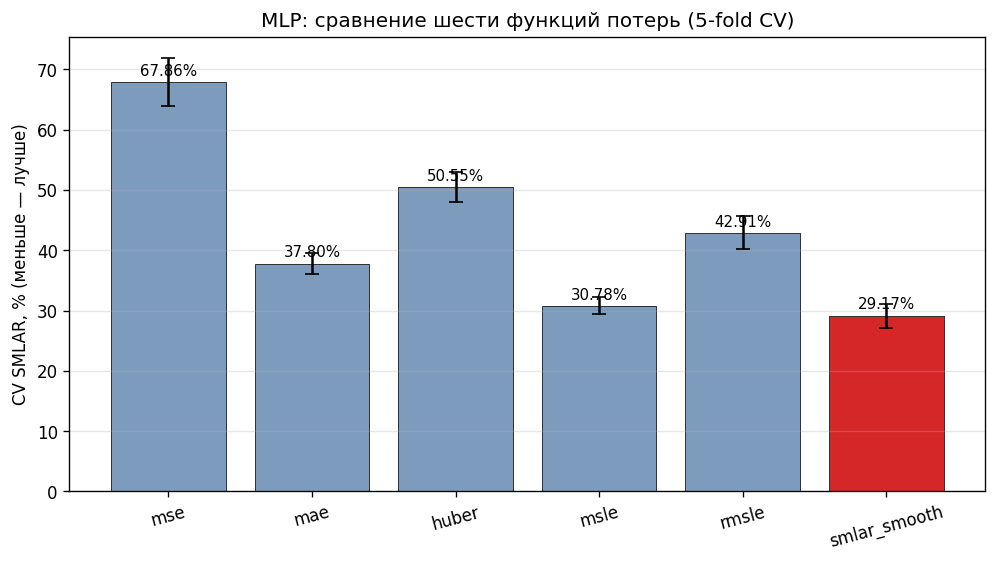

In [7]:
from IPython.display import Image
Image(OUT_DIR / 'fig_final_summary.png')

In [8]:
result = make_result(
    method=winner['name'],
    split_protocol=split['protocol'],
    leak_safe=True,
    features='leak-safe 39-feat aggregates',
    cv_smlar_flat_mean=winner['cv']['smlar_flat_mean'],
    cv_smlar_flat_std=winner['cv']['smlar_flat_std'],
    cv_smlar_per_target=winner['cv']['smlar_per_target'],
    cv_monotone_viol_mean=winner['cv']['monotone_viol_mean'],
    holdout_smlar=winner['holdout']['smlar_flat'],
    holdout_monotone_viol=winner['holdout']['monotone_viol'],
    ci_type='split_cp',
    ci_alpha=ALPHA,
    ci_coverage_per_target=winner['ci']['coverage_per_target'],
    ci_width_per_target=winner['ci']['width_per_target'],
    source='notebook 03_evaluation_and_cp',
    extra={
        'cv_smlar_per_target_std': winner['cv']['smlar_per_target_std'],
        'cv_monotone_viol_per_pair': winner['cv']['monotone_viol_per_pair'],
        'holdout_smlar_per_target': winner['holdout']['smlar_per_target'],
        'holdout_monotone_viol_per_pair': winner['holdout']['monotone_viol_per_pair'],
        'variants': [
            {'name': v['name'], 'cv': v['cv'], 'holdout': v['holdout'], 'ci': v['ci']}
            for v in variants
        ],
    },
)
json_path = save_method_results('mlp', result)
print('Записан unified-результат:', json_path)


Записан unified-результат: /Users/ensamsanovich/auc_forecast/results/per_method/mlp.json


#### Результаты
- Предсказания на holdout и интервалы Split CP при α = 0.10.
- CV SMLAR по 5 фолдам для всех 6 потерь — итоговая столбчатая диаграмма

In [ ]:
results_path = Path('/Users/ensamsanovich/auc_forecast/results') / 'per_method' / 'mlp.json'
with open(results_path) as f:
    r = json.load(f)

ho_pt = r['extra']['holdout_smlar_per_target']
for k, v in ho_pt.items():
    print(f"  {k}: {v:.2f}%")

  at_least_one: 33.75%
  at_least_two: 18.74%
  at_least_three: 16.13%
